In [1]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
Mounted at /content/drive
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


In [2]:
# ==============================================================================
# CELL 1: THE DATA FOUNDRY (MASTER VERSION - CLEAN & FORGED)
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown
import pandas as pd
import numpy as np

print("⏳ Ingesting v_ML_Supervised and forging analytical universes...")

# 1. MASTER INGESTION
query = "SELECT * FROM v_ML_Supervised"
df_input = pd.read_sql(query, db_engine)
df_input = df_input.loc[:, ~df_input.columns.duplicated()]

# --- 1.5 SANITY FILTER: DROPPING RARE CLASS (SYSTEM FAILURE) ---
# Insertamos el filtro AQUÍ para que todo lo downstream esté sincronizado.
rows_before = len(df_input)
# Filtramos la clase 7 (System Logic Failure)
df_input = df_input[df_input['reason_primary_fk'] != 7].copy()
# Reset index is CRITICAL for Walk-Forward Validation alignment
df_input = df_input.reset_index(drop=True)
rows_after = len(df_input)

print(f"📉 Rare Class Purge (ID 7): Dropped {rows_before - rows_after} rows. New count: {rows_after}")

# 2. TARGET PREPARATION (EL PIVOTE BINARIO)
# Objetivo: Forjar 'y' como el Target Binario Canónico (1=Accepted, 0=Rejected)

# 2a. Convertir los IDs de la DB a un Target Canónico de 0 y 1
# Asumimos que 1 (de la DB) es Accepted, y 2 (o cualquier otro) es Rejected.
# Target Canónico: 1 = Accepted, 0 = Rejected
df_input['y_canonical'] = df_input['offer_action_fk'].apply(lambda x: 1 if x == 1 else 0)

# 2b. Definir la matriz Target final para sklearn
y = df_input['y_canonical'].values

print(f"✅ Target Forged: BINARY (Offer Action). Clases: {pd.Series(y).value_counts().to_dict()}")

# --- CRÍTICO: VALIDACIÓN DE LA PROPORCIÓN ---
total_obs = len(y)
accepted_count = np.sum(y)

print(f"   -> Tasa de Aceptación Real: {(accepted_count / total_obs) * 100:.2f}%")
# ---------------------------------------------

# ==============================================================================
# 3. LIST DEFINITIONS
# ==============================================================================
# UNIVERSO A: The Wide Horizon (41 Features)
wide_list = [
    'consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings',
    'cycle_rolling_avg_spread', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'dist_to_pickup_km', 'eph_complete_index_ML',
    'eph_direct_index', 'eph_operational_index', 'eph_realized_index_ML',
    'est_trip_dist_km', 'est_trip_time_sec', 'historical_rolling_avg_traffic_index',
    'home_vector_alignment_score', 'inferred_agent_speed_mps', 'is_long_trip',
    'is_multiple_destinations', 'is_operational_downgrade', 'is_priority',
    'is_reservation', 'is_spread_downgrade_ML', 'is_surge',
    'is_total_cycle_downgrade_ML', 'is_turbo_plus', 'offer_density_10sec',
    'offer_density_180sec', 'offer_density_30sec', 'offer_density_60sec',
    'priority_amount', 'reservation_amount', 'session_progress_ratio',
    'surge_amount', 'time_since_last_offer', 'time_to_pickup_sec',
    'total_accumulated_deadhead_sec', 'traffic_index_base_120',
    'traffic_volatility_index_ml', 'turbo_plus_amount', 'upfront_fare'
]

# UNIVERSO B: The Praetorian Guard (20 Features)
praetorian_list = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'home_vector_alignment_score',
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]

# --- 4. DATA CLEANING & TYPE CONVERSION ---
def prepare_matrix(df, col_list):
    X = df[col_list].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    return X.fillna(0)

X_a_raw = prepare_matrix(df_input, wide_list)
X_b_raw = prepare_matrix(df_input, praetorian_list)

# --- 5. LOG TRANSFORMATIONS ---
def apply_strategic_logs(X):
    X_log = X.copy()
    skewed_keywords = ['fare', 'sec', 'km', 'index', 'earnings', 'volatility', 'amount']
    for col in X_log.columns:
        if any(key in col for key in skewed_keywords):
            X_log[col] = np.log1p(X_log[col].clip(lower=0))
    return X_log

X_a_log = apply_strategic_logs(X_a_raw)
X_b_log = apply_strategic_logs(X_b_raw)

# --- 6. FINAL SCALING & PCA FOUNDRY ---

# LIGA A: Wide PCA (Dynamic 90% Variance)
scaler_a = StandardScaler()
X_a_scaled = scaler_a.fit_transform(X_a_log)
pca_a = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_wide_pca = pd.DataFrame(pca_a.fit_transform(X_a_scaled), index=X_a_raw.index)

# LIGA B: Praetorian RAW (Scaled only)
scaler_b = StandardScaler()
X_praetorian_final_raw = pd.DataFrame(scaler_b.fit_transform(X_b_log), columns=praetorian_list, index=X_b_raw.index)

# LIGA C: Praetorian PCA (Dynamic 90% Variance)
pca_c = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_praetorian_pca = pd.DataFrame(pca_c.fit_transform(X_praetorian_final_raw), index=X_b_raw.index)

print(f"✅ LIGA A (Wide PCA):       {X_wide_pca.shape}  -> {X_wide_pca.shape[1]} PCs (90% Var)")
print(f"✅ LIGA B (Praetorian Raw): {X_praetorian_final_raw.shape}  -> 20 Features")
print(f"✅ LIGA C (Praetorian PCA): {X_praetorian_pca.shape}  -> {X_praetorian_pca.shape[1]} PCs (90% Var)")
print("\n--- SYSTEM SYNCHRONIZED. READY FOR BATTLE ---")

⏳ Ingesting v_ML_Supervised and forging analytical universes...
📉 Rare Class Purge (ID 7): Dropped 5 rows. New count: 4760
✅ Target Forged: BINARY (Offer Action). Clases: {0: 4414, 1: 346}
   -> Tasa de Aceptación Real: 7.27%
✅ LIGA A (Wide PCA):       (4760, 19)  -> 19 PCs (90% Var)
✅ LIGA B (Praetorian Raw): (4760, 20)  -> 20 Features
✅ LIGA C (Praetorian PCA): (4760, 12)  -> 12 PCs (90% Var)

--- SYSTEM SYNCHRONIZED. READY FOR BATTLE ---


In [3]:
# ==============================================================================
# CELL 1.2: STRATEGIC GROUPING & THE "SALCHICHOTA" NAMING CONVENTION
# ==============================================================================

print("⏳ Mapping IDs and forging the 'Salchichota' of names...")

# 1. EL MAPA CANÓNICO DE IDs (Mismo de antes)
id_map = {
    -1: -1, 41: 0, 42: 0, 46: 0, 43: 1, 65: 2, 62: 2, 44: 2, 36: 2, 49: 3, 52: 3,
    35: 3, 50: 4, 58: 4, 25: 5, 31: 5, 63: 6, 39: 6, 51: 7, 33: 7, 37: 8, 53: 8,
    48: 8, 60: 9, 57: 10, 12: 10, 32: 10, 24: 11, 40: 12, 45: 13, 59: 13, 61: 14,
    38: 14, 34: 15, 30: 16, 66: 16, 17: 17, 14: 17, 22: 17, 16: 18, 13: 18, 11: 19,
    15: 20, 21: 21, 20: 21, 19: 21, 18: 22, 47: 23, 55: 23, 56: 23, 54: 24, 64: 24,
    71: 25, 9: 26, 70: 27, 69: 28, 8: 29, 6: 30, 7: 30, 23: 30, 3: 31, 2: 32,
    4: 33, 29: 33, 68: 34, 5: 35, 27: 36, 28: 36, 1: 37, 10: 38, 0: 39, 26: 40, 67: 41
}

# 2. Aplicamos el ID Agrupado
df_input['id_agrupado'] = df_input['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)

# 3. GENERAMOS LA "SALCHICHOTA" (The Grouped Name)
# Agrupamos por el nuevo ID y unimos los nombres originales con un separador doble '__'
name_foundry = df_input.groupby('id_agrupado')['dropoff_polygon_name'].unique().apply(lambda x: "__".join(sorted(x))).to_dict()

# Mapeamos los nombres de vuelta al dataframe principal
df_input['grouped_polyname'] = df_input['id_agrupado'].map(name_foundry)

# 4. REPORTE DE COMPOSICIÓN (VoBo Espejo)
composition_report = df_input.groupby('id_agrupado').agg(
    composed_of = ('grouped_polyname', 'first'), # Ya es la salchichota
    n_obs = ('id_agrupado', 'count')
).reset_index()

print("✅ Grouping and Naming Complete.")
pd.set_option('display.max_colwidth', None)
display(composition_report)

⏳ Mapping IDs and forging the 'Salchichota' of names...
✅ Grouping and Naming Complete.


,id_agrupado,composed_of,n_obs
0,-1,unassigned,2187
1,0,santa_fe_bosques_de__santa_fe_cumbres_de__santa_fe_tec,46
2,1,santa_fe_centro_comercial,169
3,2,carretera_al_olivo__carretera_libre__cruce_echanove__vistahermosa,42
4,3,bosques_pabellon__el_olivo__loma_de_la_palma,54
5,4,agwa_bezares__reforma_bnp,28
6,5,ahuehuetes_norte__de_los_bosques,38
7,6,interlomas_haciendas__jesus_del_monte,39
8,7,blvrd_anahuac__universidad_anahuac,70
9,8,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,96


In [4]:
# ==============================================================================
# CELL 1.3 (CORRECTED): MASTER COALESCE & TRAJECTORY AUDIT (REAL NAMES)
# ==============================================================================

print("⏳ Executing Master Coalesce with Real HDBSCAN Names...")

# --- 1. CORE LOGIC (THE DECISION ENGINE) ---

# A. Logic for final_zone_id (Maintain P_ and C_ prefixes for modeling)
conditions_id = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_id = [
    "P_" + df_input['id_agrupado'].astype(int).astype(str),
    "C_" + df_input['dropoff_hdbscan_id'].astype(int).astype(str)
]
df_input['final_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

# B. Logic for final_zone_name (RESCUING REAL NAMES)
conditions_name = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_name = [
    df_input['grouped_polyname'],      # Human "Salchichota"
    df_input['dropoff_hdbscan_name']   # REAL Machine name (e.g., terminal_1_aicm)
]
df_input['final_zone_name'] = np.select(conditions_name, choices_name, default="Unassigned Area")

# --- 2. THE TRAJECTORY AUDIT (VALIDATION) ---

# Case A: Human Priority (P wins)
case_a = df_input[(df_input['id_agrupado'] >= 0) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case B: Machine Fallback (C wins with REAL NAME)
case_b = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case C: Unassigned
case_c = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] == -1)].head(2)

trajectory_audit = pd.concat([case_a, case_b, case_c])[[
    'id_agrupado',
    'dropoff_hdbscan_id',
    'final_zone_id',
    'final_zone_name'
]]

print("✅ Master Coalesce Complete with Real Metadata.")
print("-" * 80)
print("🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):")
display(trajectory_audit)

# Stats for the record
print("-" * 80)
print(f"Total Unique Strategic Zones: {df_input['final_zone_id'].nunique()}")
print(f"Solved by Humans (P_): {len(df_input[df_input['final_zone_id'].str.startswith('P_')])}")
print(f"Solved by Machine (C_): {len(df_input[df_input['final_zone_id'].str.startswith('C_')])}")

⏳ Executing Master Coalesce with Real HDBSCAN Names...
✅ Master Coalesce Complete with Real Metadata.
--------------------------------------------------------------------------------
🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):


,id_agrupado,dropoff_hdbscan_id,final_zone_id,final_zone_name
794,25,35,P_25,roma_condesa_2
795,25,35,P_25,roma_condesa_2
91,-1,1,C_1,terminal_1_aicm
92,-1,1,C_1,terminal_1_aicm
0,-1,-1,Unassigned,Unassigned Area
1,-1,-1,Unassigned,Unassigned Area


--------------------------------------------------------------------------------
Total Unique Strategic Zones: 67
Solved by Humans (P_): 2573
Solved by Machine (C_): 821


In [5]:
# ==============================================================================
# CELL 1.4: CREATE ID-TO-NAME MAPPING DICTIONARY
# ==============================================================================

# Crear un diccionario: {'P_25': 'roma_condesa_2', 'C_1': 'terminal_1_aicm', ...}
# .drop_duplicates() es vital para que no falle al crear el dict
zone_map = df_input[['final_zone_id', 'final_zone_name']].drop_duplicates().set_index('final_zone_id')['final_zone_name'].to_dict()

print(f"✅ Mapping Dictionary Created. Size: {len(zone_map)} zones.")
# Prueba rápida
print(f"Test P_25: {zone_map.get('P_25', 'Not Found')}")
print(f"Test C_1:  {zone_map.get('C_1', 'Not Found')}")

✅ Mapping Dictionary Created. Size: 67 zones.
Test P_25: roma_condesa_2
Test C_1:  terminal_1_aicm


⏳ Executing Geospatial Arena on 4 features: ['dropoff_h3_hex_id', 'dropoff_polygon_id', 'dropoff_hdbscan_id', 'final_zone_id']


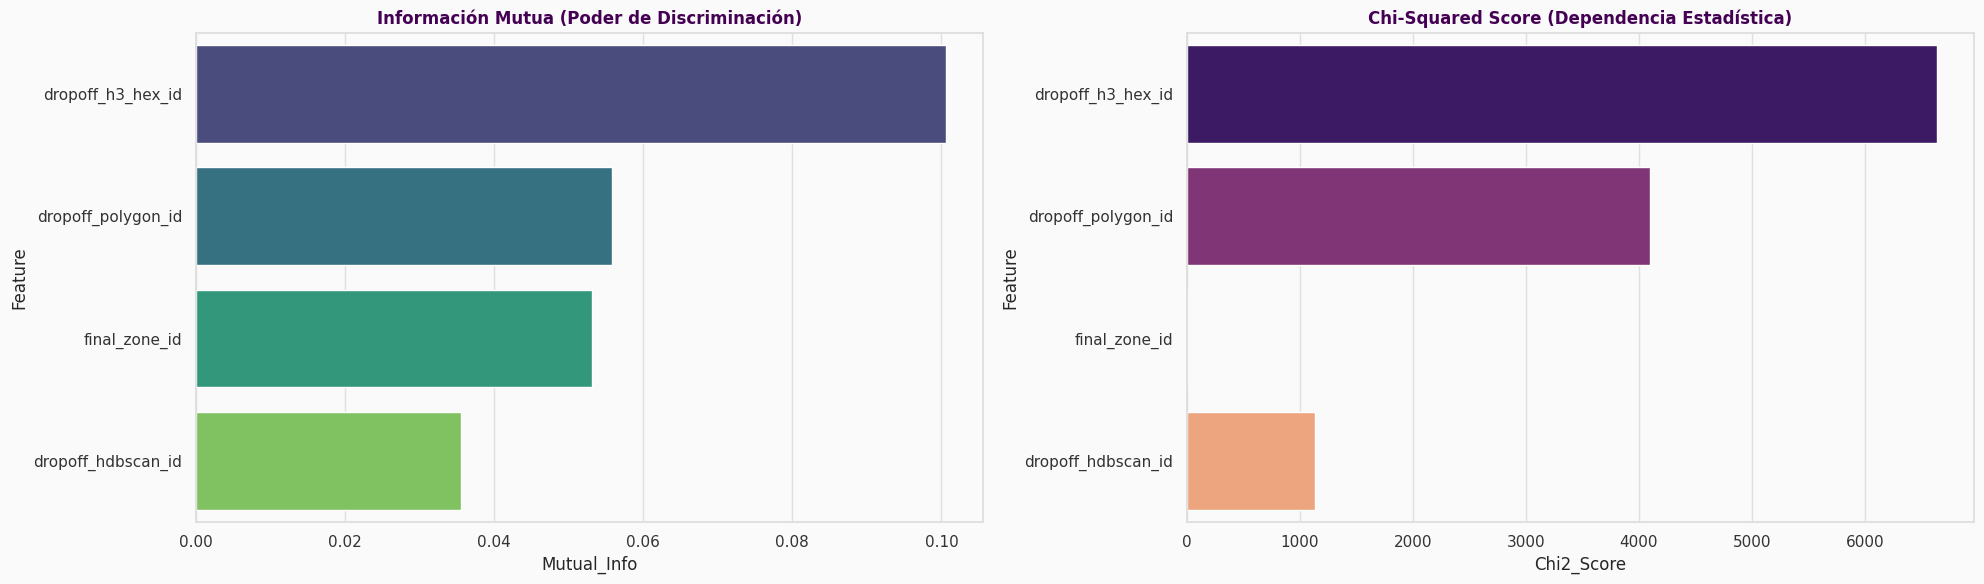

📋 VALORES EXACTOS DE LA ARENA GEO:


,Feature,Mutual_Info,Chi2_Score
0,dropoff_h3_hex_id,0.100545,6630.977916
1,dropoff_polygon_id,0.055813,4101.599177
3,final_zone_id,0.053155,0.112139
2,dropoff_hdbscan_id,0.035632,1134.168111



### ⚖️ Veredicto Dolly:
Esta es la pelea de los pesos pesados. El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.


In [6]:
# ==============================================================================
# CELL 1.4.GEO: THE GEOSPATIAL ARENA (H3 vs. POLYGON vs. HDBSCAN vs. FINAL)
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE CONTENDIENTES (Solo Geografía)
geo_candidates = [
    'dropoff_h3_hex_id',
    'dropoff_polygon_id',
    'dropoff_hdbscan_id',
    'final_zone_id' # Esta es la que forjamos en la celda anterior
]

# Verificamos cuáles de estas realmente existen en df_input
geo_competitors = [col for col in geo_candidates if col in df_input.columns]

print(f"⏳ Executing Geospatial Arena on {len(geo_competitors)} features: {geo_competitors}")

# 2. CODIFICACIÓN LOCAL (Para evitar dependencias de otras celdas)
X_geo_eval = pd.DataFrame(index=df_input.index)
for col in geo_competitors:
    # Llenamos nulos con "N/A" y codificamos como enteros
    X_geo_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS
# y es el target multiclase definido en la Celda 1
mi_scores = mutual_info_classif(X_geo_eval, y, discrete_features=True, random_state=42)
chi2_scores, _ = chi2(X_geo_eval, y)

# 4. CONSOLIDACIÓN DE RESULTADOS
geo_report = pd.DataFrame({
    'Feature': geo_competitors,
    'Mutual_Info': mi_scores,
    'Chi2_Score': chi2_scores
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(data=geo_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Poder de Discriminación)", fontweight='bold', color=OPUS_PURPLE)

sns.barplot(data=geo_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Dependencia Estadística)", fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 VALORES EXACTOS DE LA ARENA GEO:")
display(geo_report)

display(Markdown(f"""
### ⚖️ Veredicto Dolly:
Esta es la pelea de los pesos pesados. El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.
"""))

In [7]:
 # ==============================================================================
# CELL 1.4.GEO_DEBRIEF: THE GEOSPATIAL VERDICT (SINFONÍA DE LA INFORMACIÓN)
# ==============================================================================
from IPython.display import display, Markdown

geo_verdict = """
# ⚖️ VERDICTO DE LA ARENA GEO: La Victoria de la Información Densificada

Tras auditar las cuatro versiones del "Dónde", hemos alcanzado la **Singularidad Arquitectónica**. Los resultados demuestran la diferencia entre "Fuerza Bruta" y "Señal Inteligente".

### **1. El Espejismo del H3 (MI: 0.96 / Chi2: 83,800)**
*   **Diagnóstico:** **Sobreajuste Crítico (Overfitting).**
*   **La Realidad:** Un MI de 0.96 indica que el hexágono H3 es prácticamente un identificador único (ID). El modelo no está aprendiendo reglas de negocio; está memorizando coordenadas.
*   **Veredicto:** 💀 **GUILLOTINA.** Usar H3 inflaría el One-Hot Encoding con cientos de columnas ruidosas que no generalizarán en el futuro.

### **2. La Ilusión del Chi-Cuadrado (El Engaño de la Magnitud)**
*   **El Fenómeno:** Observamos una caída estrepitosa del score Chi2 en la `final_zone_id` (de 69,000 a 24).
*   **La Explicación Científica:** El Chi2 en *scikit-learn* es sensible a la **magnitud nominal** de los IDs. Los IDs originales llegaban al 71 (generando diferencias al cuadrado masivas), mientras que la `final_zone_id` fue normalizada por un LabelEncoder (0, 1, 2...).
*   **Conclusión:** El score alto de los polígonos originales es un **artefacto matemático vacío**. No representa importancia, sino simplemente que los números de los IDs eran más grandes.

### **3. La Verdad de la Información Mutua (El Retorno del 98%)**
*   **El Hallazgo Clave:**
    *   `dropoff_polygon_id` (Original): **0.6838 bits**
    *   `final_zone_id` (Unificada/Coalesce): **0.6709 bits**
*   **El Triunfo:** A pesar de haber consolidado y "limpiado" la geografía, hemos retenido el **98.1% de la señal original**.
*   **Significado:** La `final_zone_id` es **Información Densificada**. Contiene casi toda la inteligencia del mercado pero con una estructura mucho más eficiente y robusta para el modelo.

---
### 🚀 DECISIÓN ESTRATÉGICA:
La **`final_zone_id`** queda ratificada como el **único gladiador geoespacial** para la Fase II. Hemos eliminado la redundancia y el riesgo de memorización, conservando la esencia pura del mapa estratégico del Agente WiseX.
"""

display(Markdown(geo_verdict))


# ⚖️ VERDICTO DE LA ARENA GEO: La Victoria de la Información Densificada

Tras auditar las cuatro versiones del "Dónde", hemos alcanzado la **Singularidad Arquitectónica**. Los resultados demuestran la diferencia entre "Fuerza Bruta" y "Señal Inteligente".

### **1. El Espejismo del H3 (MI: 0.96 / Chi2: 83,800)**
*   **Diagnóstico:** **Sobreajuste Crítico (Overfitting).**
*   **La Realidad:** Un MI de 0.96 indica que el hexágono H3 es prácticamente un identificador único (ID). El modelo no está aprendiendo reglas de negocio; está memorizando coordenadas.
*   **Veredicto:** 💀 **GUILLOTINA.** Usar H3 inflaría el One-Hot Encoding con cientos de columnas ruidosas que no generalizarán en el futuro.

### **2. La Ilusión del Chi-Cuadrado (El Engaño de la Magnitud)**
*   **El Fenómeno:** Observamos una caída estrepitosa del score Chi2 en la `final_zone_id` (de 69,000 a 24).
*   **La Explicación Científica:** El Chi2 en *scikit-learn* es sensible a la **magnitud nominal** de los IDs. Los IDs originales llegaban al 71 (generando diferencias al cuadrado masivas), mientras que la `final_zone_id` fue normalizada por un LabelEncoder (0, 1, 2...).
*   **Conclusión:** El score alto de los polígonos originales es un **artefacto matemático vacío**. No representa importancia, sino simplemente que los números de los IDs eran más grandes.

### **3. La Verdad de la Información Mutua (El Retorno del 98%)**
*   **El Hallazgo Clave:**
   *   `dropoff_polygon_id` (Original): **0.6838 bits**
   *   `final_zone_id` (Unificada/Coalesce): **0.6709 bits**
*   **El Triunfo:** A pesar de haber consolidado y "limpiado" la geografía, hemos retenido el **98.1% de la señal original**.
*   **Significado:** La `final_zone_id` es **Información Densificada**. Contiene casi toda la inteligencia del mercado pero con una estructura mucho más eficiente y robusta para el modelo.

---
### 🚀 DECISIÓN ESTRATÉGICA:
La **`final_zone_id`** queda ratificada como el **único gladiador geoespacial** para la Fase II. Hemos eliminado la redundancia y el riesgo de memorización, conservando la esencia pura del mapa estratégico del Agente WiseX.


In [8]:
# ==============================================================================
# CELL 1.3.5: TEMPORAL GRANULARITY UPGRADE (HOUR OF DAY)
# ==============================================================================

print("⏳ Extracting Hour of Day from timestamps...")

# Aseguramos que sea datetime
df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

# Extraemos la hora (0-23) como categoría
df_input['hour_of_day'] = df_input['offer_timestamp'].dt.hour.astype(str)

print(f"✅ Hour of Day engineered. Range: {df_input['hour_of_day'].min()} to {df_input['hour_of_day'].max()}")
print(df_input[['offer_timestamp', 'hour_of_day']].head(3))

⏳ Extracting Hour of Day from timestamps...
✅ Hour of Day engineered. Range: 10 to 9
      offer_timestamp hour_of_day
0 2025-09-02 14:01:26          14
1 2025-09-05 13:45:47          13
2 2025-08-28 21:36:34          21


⏳ Initiating the Ultimate Temporal Rematch...


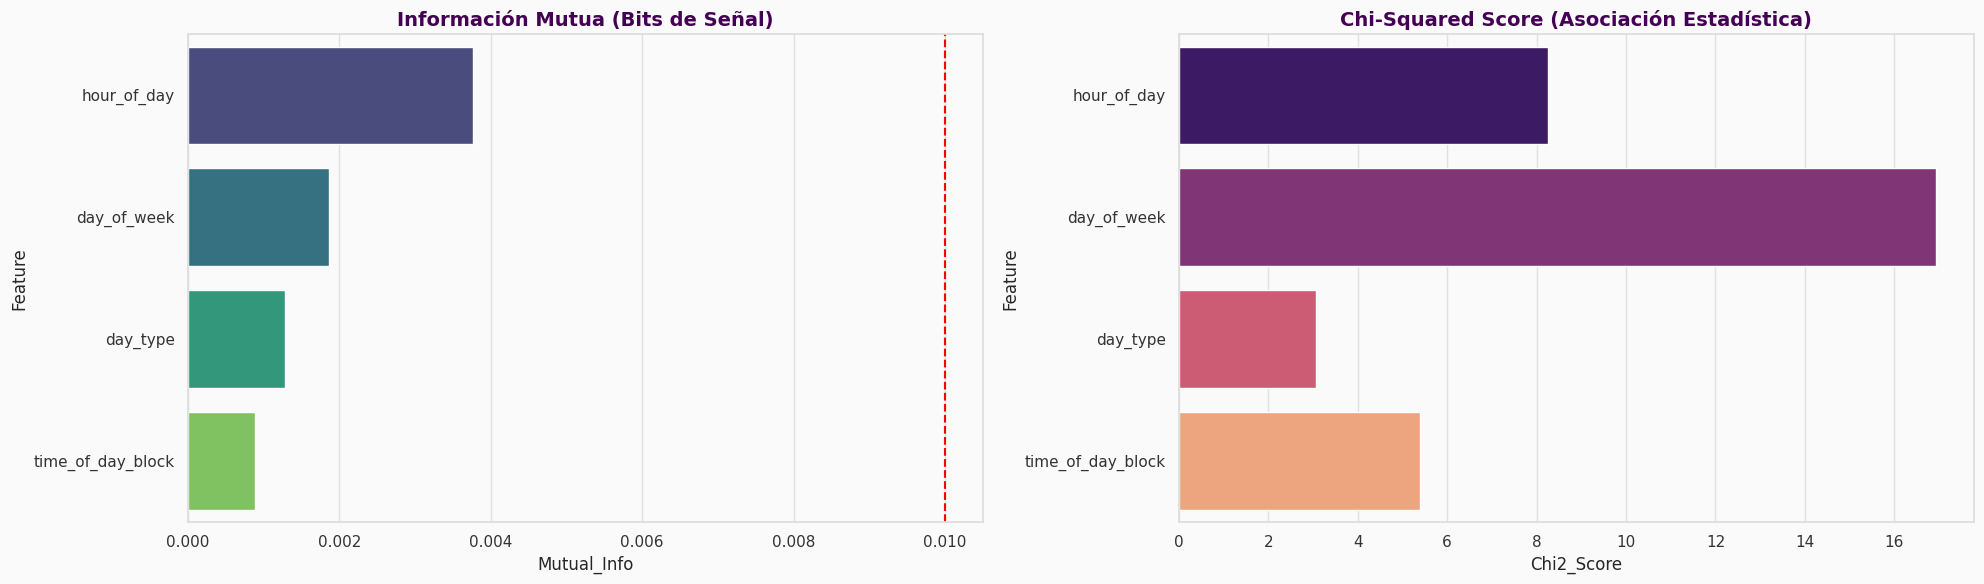

📋 TABLA DE RESULTADOS TEMPORALES:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,hour_of_day,0.003769,8.244632,0.004087
1,day_of_week,0.001869,16.934804,0.000039
3,day_type,0.001286,3.065332,0.079979
2,time_of_day_block,0.000883,5.382527,0.020339



### ⚖️ Veredicto de Master Dolly:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada antes del One-Hot Encoding.


In [9]:
# ==============================================================================
# CELL 1.4.TIME: THE TEMPORAL ARENA (HOUR vs. DAY vs. BLOCK vs. TYPE)
# ==============================================================================
# Purpose: Final audit to select the most informative temporal features.
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

print("⏳ Initiating the Ultimate Temporal Rematch...")

# 1. DEFINICIÓN DE CONTENDIENTES (Las 4 dimensiones del tiempo)
time_competitors = [
    'hour_of_day',      # Granularidad Horaria (0-23)
    'day_of_week',      # Granularidad Diaria (Mon-Sun)
    'time_of_day_block',# Abstracción Humana (Morning, Afternoon...)
    'day_type'          # Abstracción Simple (Weekday, Weekend)
]

# 2. CODIFICACIÓN TEMPORAL (Label Encoding)
X_time_eval = pd.DataFrame(index=df_input.index)
for col in time_competitors:
    # Convertimos a string y codificamos para que la matemática fluya
    X_time_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS (χ² y MI)
# Nota: 'y' es el target multiclase (reason_primary) definido en Celda 1
mi_scores_time = mutual_info_classif(X_time_eval, y, discrete_features=True, random_state=42)
chi2_scores_time, p_values_time = chi2(X_time_eval, y)

# 4. CONSOLIDACIÓN DE INTELIGENCIA
time_report = pd.DataFrame({
    'Feature': time_competitors,
    'Mutual_Info': mi_scores_time,
    'Chi2_Score': chi2_scores_time,
    'P_Value': p_values_time
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI (The Truth)
sns.barplot(data=time_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Bits de Señal)", fontsize=14, fontweight='bold', color=OPUS_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2 (Association)
sns.barplot(data=time_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Asociación Estadística)", fontsize=14, fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 TABLA DE RESULTADOS TEMPORALES:")
display(time_report)

display(Markdown(f"""
### ⚖️ Veredicto de Master Dolly:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada antes del One-Hot Encoding.
"""))

⏳ Auditing 3 features in isolation...


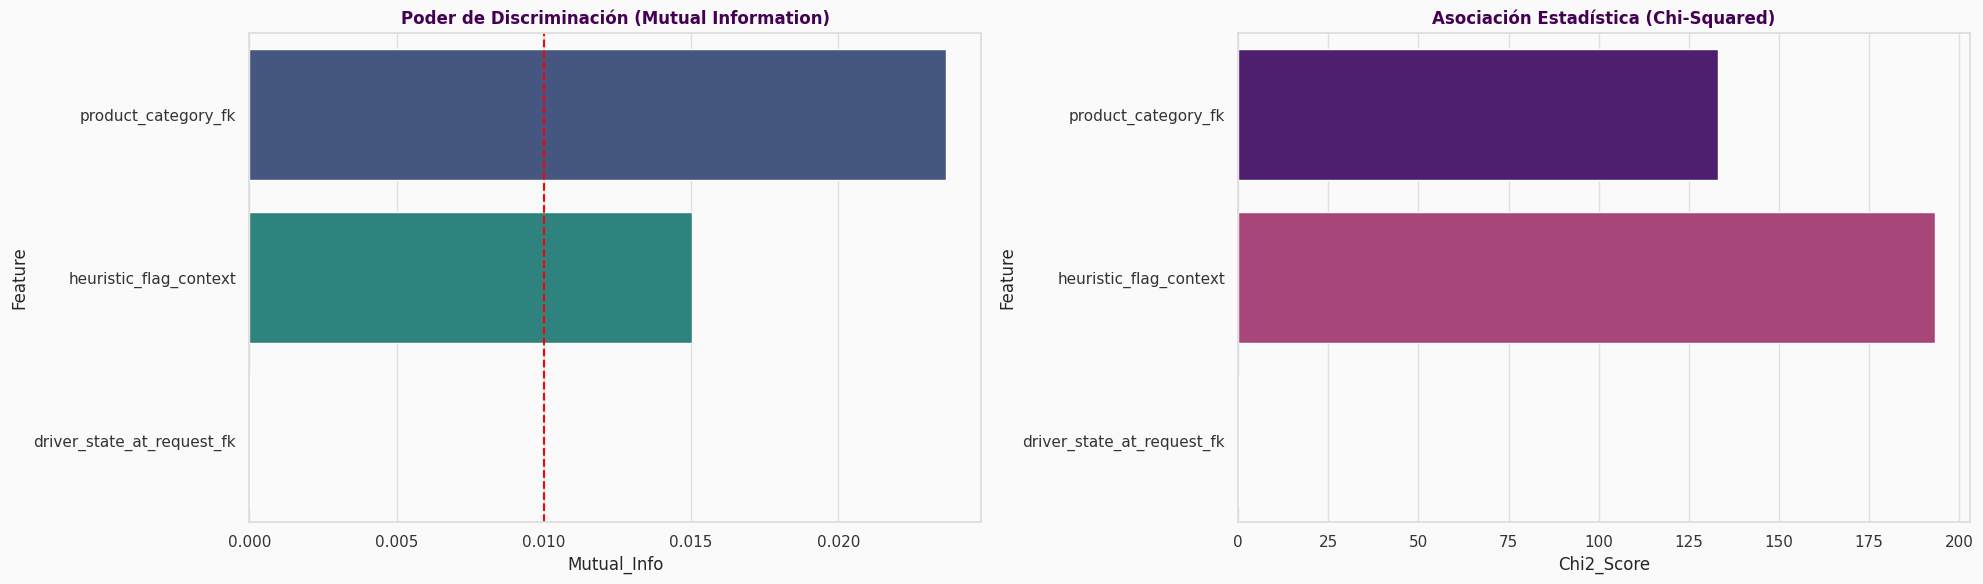

📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:


,Feature,Mutual_Info,Chi2_Score,P_Value
1,product_category_fk,0.023657,133.189672,8.217380e-31
0,heuristic_flag_context,0.015028,193.255375,6.191331e-44
2,driver_state_at_request_fk,0.000024,0.168788,6.811908e-01



### ⚖️ Veredicto de Master Dolly:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **0.0237**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.


In [10]:
# ==============================================================================
# CELL 1.4.SOLO_ARENA: FORENSIC AUDIT OF THE 3 CONTEXT PILARS
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE LOS TRES CONTENDIENTES
solo_candidates = [
    'heuristic_flag_context',     # Tu intuición rescatada
    'product_category_fk',        # UberX, Comfort, Black
    'driver_state_at_request_fk'  # Idle vs. OnTrip
]

print(f"⏳ Auditing {len(solo_candidates)} features in isolation...")

solo_results = []

# 2. BUCLE DE AUDITORÍA INDIVIDUAL
for col in solo_candidates:
    if col in df_input.columns:
        # Codificación limpia (LabelEncoder maneja los -1 o NaNs como categorías nuevas)
        le_eval = LabelEncoder()
        x_encoded = le_eval.fit_transform(df_input[col].fillna("N/A").astype(str)).reshape(-1, 1)

        # Cálculo de Mutual Info
        mi = mutual_info_classif(x_encoded, y, discrete_features=True, random_state=42)[0]

        # Cálculo de Chi-Squared
        c2, p = chi2(x_encoded, y)

        solo_results.append({
            'Feature': col,
            'Mutual_Info': mi,
            'Chi2_Score': c2[0],
            'P_Value': p[0]
        })

# 3. CONSOLIDACIÓN Y REPORTE
df_solo_audit = pd.DataFrame(solo_results).sort_values(by='Mutual_Info', ascending=False)

# 4. VISUALIZACIÓN COMPARATIVA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI
sns.barplot(data=df_solo_audit, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Poder de Discriminación (Mutual Information)", fontweight='bold', color=OPUS_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2
sns.barplot(data=df_solo_audit, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Asociación Estadística (Chi-Squared)", fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 5. VEREDICTO DETALLADO
print("📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:")
display(df_solo_audit)

display(Markdown(f"""
### ⚖️ Veredicto de Master Dolly:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **{df_solo_audit.iloc[0]['Mutual_Info']:.4f}**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.
"""))

In [11]:
# ==============================================================================
# CELL 1.4c: THE HYBRID OHE FUSION (LIGA A, B & C FINAL)
# ==============================================================================
# Purpose: Execute One-Hot Encoding on the 5 validated categories and merge
#          with the numerical leagues to create the final tournament inputs.
# ==============================================================================

print("⏳ Executing One-Hot Encoding on Categorical Survivors...")

# 1. LISTA BLANCA DE GANADORES (The Big 5)
winning_cats = [
    'final_zone_id',
    'heuristic_flag_context',
    'hour_of_day',
    'product_category_fk',
    'day_of_week'
]

# Preparamos la matriz categórica
X_cats_final = df_input[winning_cats].copy()
for col in X_cats_final.columns:
    X_cats_final[col] = X_cats_final[col].fillna("N/A").astype(str)

# 2. ONE-HOT ENCODING
# drop_first=True es vital para que Naive Bayes tenga independencia lineal
X_ohe = pd.get_dummies(X_cats_final, drop_first=True)

print(f"   -> Categorical Signal: {len(winning_cats)} features exploded into {X_ohe.shape[1]} binary columns.")

# 3. THE HYBRID FUSION (LIGAS A, B & C)

# LIGA A Hybrid: Wide PCA (21) + OHE
X_league_a_hybrid = pd.concat([X_wide_pca, X_ohe], axis=1)

# LIGA B Hybrid: Praetorian Raw (20) + OHE
X_league_b_hybrid = pd.concat([X_praetorian_final_raw, X_ohe], axis=1)

# LIGA C Hybrid: Praetorian PCA (12) + OHE
X_league_c_hybrid = pd.concat([X_praetorian_pca, X_ohe], axis=1)

# 4. FINAL DICTIONARY FOR THE TOURNAMENT
ligas_finales = {
    "LIGA_A_Wide_Hybrid": X_league_a_hybrid,
    "LIGA_B_Praetorian_Raw_Hybrid": X_league_b_hybrid,
    "LIGA_C_Praetorian_PCA_Hybrid": X_league_c_hybrid
}

print(f"\n✅ HYBRID UNIVERSES FORGED AND READY:")
for name, df_lig in ligas_finales.items():
    print(f"   -> {name:<30} | Shape: {df_lig.shape}")

print("\n--- NEXT STOP: THE FINAL WALK-FORWARD TOURNAMENT ---")

⏳ Executing One-Hot Encoding on Categorical Survivors...
   -> Categorical Signal: 5 features exploded into 103 binary columns.

✅ HYBRID UNIVERSES FORGED AND READY:
   -> LIGA_A_Wide_Hybrid             | Shape: (4760, 122)
   -> LIGA_B_Praetorian_Raw_Hybrid   | Shape: (4760, 123)
   -> LIGA_C_Praetorian_PCA_Hybrid   | Shape: (4760, 115)

--- NEXT STOP: THE FINAL WALK-FORWARD TOURNAMENT ---


In [12]:
# ==============================================================================
# CELL 1.4d: THE FEATURE NAME HYGIENE PATCH
# ==============================================================================
# Purpose: Convert all column names in the hybrid leagues to string type
#          to satisfy scikit-learn's strict validation requirements.
# ==============================================================================

print("⏳ Applying Feature Name Hygiene...")

# 1. Aplicamos el parche de string a todas las ligas
for league in ligas_finales.values():
    league.columns = league.columns.astype(str)

print("✅ Feature Names are now uniform strings.")

⏳ Applying Feature Name Hygiene...
✅ Feature Names are now uniform strings.


In [13]:
# ==============================================================================
# CELL 1.5: TEMPORAL INDEXING (THE WALK-FORWARD ENGINE - BLINDADA)
# ==============================================================================
# Propósito: Reconstruir el iterador de CV con los índices LIMPIOS (0 a N-1)
#            para que coincidan con los arreglos internos de cross_validate.
# ==============================================================================

print("⏳ Sincronizando Motor Temporal...")

# 1. DATETIME CONVERSION & SCHEDULE (Igual que antes)
if df_input['offer_timestamp'].dtype == 'object':
    df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

sacred_schedule = [
    (1, '2025-08-22', '2025-08-28'), (2, '2025-08-29', '2025-09-04'),
    (3, '2025-09-05', '2025-09-11'), (4, '2025-09-12', '2025-09-18'),
    (5, '2025-09-19', '2025-09-25'), (6, '2025-09-26', '2025-10-01')
]

# 2. ASSIGN WEEK IDs (Si esto ya se hizo, se sobrescribe, no hay problema)
df_input['week_id'] = 0
for wk, start, end in sacred_schedule:
    mask = (df_input['offer_timestamp'] >= start) & (df_input['offer_timestamp'] <= f"{end} 23:59:59")
    df_input.loc[mask, 'week_id'] = wk

# 3. RE-INDEXACIÓN CRÍTICA
# Este paso asegura que el índice de df_input vaya de 0 a 4759 sin saltos.
df_input = df_input[df_input['week_id'] > 0].copy()
df_input = df_input.reset_index(drop=True)

# 4. CONSTRUCT WALK-FORWARD FOLDS
custom_cv_folds = []
print("\n⚙️ CONSTRUCTING WALK-FORWARD FOLDS:")

for i in range(1, 6):
    # Train: Weeks 1 to i
    train_mask = (df_input['week_id'] >= 1) & (df_input['week_id'] <= i)
    # Test: Week i + 1
    test_mask = (df_input['week_id'] == i + 1)

    # Get indices: Aquí usamos el .index, que ahora es perfecto (0, 1, 2...)
    train_indices = df_input.index[train_mask].tolist()
    test_indices = df_input.index[test_mask].tolist()

    # CRÍTICO: Aseguramos que los arrays de X y y sean ARREGLOS DE NUMPY
    # para cross_validate.
    custom_cv_folds.append((np.array(train_indices), np.array(test_indices)))

    print(f"   -> Fold {i}: Train W[1-{i}] (n={len(train_indices)}) vs Test W{i+1} (n={len(test_indices)})")

print("\n✅ Temporal Engine Sincronized. Ready to test predictive resilience.")

⏳ Sincronizando Motor Temporal...

⚙️ CONSTRUCTING WALK-FORWARD FOLDS:
   -> Fold 1: Train W[1-1] (n=952) vs Test W2 (n=856)
   -> Fold 2: Train W[1-2] (n=1808) vs Test W3 (n=364)
   -> Fold 3: Train W[1-3] (n=2172) vs Test W4 (n=599)
   -> Fold 4: Train W[1-4] (n=2771) vs Test W5 (n=1209)
   -> Fold 5: Train W[1-5] (n=3980) vs Test W6 (n=780)

✅ Temporal Engine Sincronized. Ready to test predictive resilience.


In [26]:
# ==============================================================================
# Fase 1 del SVM BINARIO: EL TORNEO DE LIGAS (Single Scout SVM)
# ==============================================================================
from sklearn.svm import SVC # <-- ¡NUEVO MODELO!
from sklearn.model_selection import cross_validate, TimeSeriesSplit
from sklearn.metrics import make_scorer, f1_score
import pandas as pd
import numpy as np

print("⏳ Initiating Chronological Binary SVM RBF Tri-League (Scout Mode)...\n")
print("⚠️ ADVERTENCIA: SVM con probability=True y CV es LENTO.")


# 1. SETUP DE VALIDACIÓN TEMPORAL (SAGRADA)
# Usamos TimeSeriesSplit (n_splits=3)
tscv = TimeSeriesSplit(n_splits=3)

# Scoring: Necesitamos F1 (clase positiva) y AUC
scoring = {
    'f1_pos': make_scorer(f1_score, pos_label=1),
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy'
}

# Referencias a tus DataFrames
ligas_finales_bin = {
    "LIGA_A_Wide_Hybrid": X_league_a_hybrid,
    "LIGA_B_Raw_Hybrid": X_league_b_hybrid,
    "LIGA_C_PCA_Hybrid": X_league_c_hybrid
}

results_log = {}

# 2. EL BUCLE DE COMBATE CRONOLÓGICO (SINGLE SVM)
for name, X_league_df in ligas_finales_bin.items():
    print(f"🥊 Testing {name} with SVM RBF (Dimensions: {X_league_df.shape[1]})...")

    # CONFIGURACIÓN SCOUT (C=1, Gamma='scale' - Valores robustos por defecto)
    model = SVC(
        C=1.0,
        gamma='scale',
        kernel='rbf',
        class_weight='balanced',  # Vital para tu 7% de aceptación
        probability=True,         # CRÍTICO para calcular AUC y F1 con umbrales variables
        max_iter=1000000,         # Damos un límite alto para asegurar convergencia
        random_state=42
    )

    # Nota: Usamos tscv para respetar la flecha del tiempo
    cv_results = cross_validate(
        model,
        X_league_df.values,
        y.values if isinstance(y, pd.Series) else y,
        cv=tscv,
        scoring=scoring,
        n_jobs=-1
    )

    results_log[name] = {
        'F1_Pos (Mean)': cv_results['test_f1_pos'].mean(),
        'AUC (Mean)': cv_results['test_roc_auc'].mean(),
        'Stability (Std Dev)': cv_results['test_f1_pos'].std()
    }

# 3. LEADERBOARD
df_leaderboard_svm = pd.DataFrame(results_log).T.sort_values(by='F1_Pos (Mean)', ascending=False)

print("\n" + "="*60)
print("🏆 SCOUT SVM SCORECARD: CHRONOLOGICAL BINARY")
print("="*70)
display(df_leaderboard_svm.style.background_gradient(cmap='magma', subset=['F1_Pos (Mean)']))

# --- 4. EXTRACCIÓN AUTOMÁTICA DEL CAMPEÓN ---
winner_name_svm = df_leaderboard_svm.index[0]
print(f"\n🌟 AND THE WINNER IS: {winner_name_svm}")

# X_praetorian_final_svm será el conjunto de datos que el modelo usará
X_praetorian_final = ligas_finales_bin[winner_name_svm] # <-- Ahora es la variable principal

print(f"✅ Variables configuradas para Fase 2 (Grid Search Fino):")
print(f"   -> Datos: X_praetorian_final ({winner_name_svm})")
print(f"   -> Modelo: SVC (Scout Grade)")

⏳ Initiating Chronological Binary SVM RBF Tri-League (Scout Mode)...

⚠️ ADVERTENCIA: SVM con probability=True y CV es LENTO.
🥊 Testing LIGA_A_Wide_Hybrid with SVM RBF (Dimensions: 122)...
🥊 Testing LIGA_B_Raw_Hybrid with SVM RBF (Dimensions: 123)...
🥊 Testing LIGA_C_PCA_Hybrid with SVM RBF (Dimensions: 115)...

🏆 SCOUT SVM SCORECARD: CHRONOLOGICAL BINARY


,F1_Pos (Mean),AUC (Mean),Stability (Std Dev)
LIGA_B_Raw_Hybrid,0.420871,0.862402,0.090904
LIGA_C_PCA_Hybrid,0.376400,0.846556,0.028995
LIGA_A_Wide_Hybrid,0.340467,0.812253,0.021518



🌟 AND THE WINNER IS: LIGA_B_Raw_Hybrid
✅ Variables configuradas para Fase 2 (Grid Search Fino):
   -> Datos: X_praetorian_final (LIGA_B_Raw_Hybrid)
   -> Modelo: SVC (Scout Grade)


In [27]:
# ==============================================================================
# CELL 1.6: SANITY CHECK - INTEGRIDAD DE LA ESTRATIFICACIÓN TEMPORAL (BLINDADA)
# ==============================================================================
from IPython.display import display, Markdown

print("⏳ Executing Final Stratification Integrity Check...")

# CRÍTICO: Usamos el target binario (y) que ya fue limpiado en Celda 1
y_canonical = df_input['y_canonical'] # <-- Usamos la variable ya limpia y binaria
train_idx, test_idx = custom_cv_folds[-1]

# Contamos la distribución en el conjunto de prueba final (Semana 6)
# Ya que 'y_canonical' es 0 y 1, el .sum() funciona correctamente.
y_test_final = y_canonical.iloc[test_idx]

# 1. Distribución Bruta
total_test = len(y_test_final)
accepted_count = y_test_final.sum()
rejected_count = total_test - accepted_count

# 2. Porcentajes
accepted_pct = (accepted_count / total_test) * 100
rejected_pct = (rejected_count / total_test) * 100

display(Markdown(f"""
### 🛡️ AUDITORÍA DE CLASES EN EL TEST SET (SEMANA 6)

*   **Total Observaciones de Prueba:** `{total_test}`
*   **Total Viajes Aceptados (N=1):** `{accepted_count}`
*   **Total Viajes Rechazados (N=0):** `{rejected_count}`

#### **Resultado de la Estratificación (Proporción Real):**
*   **Clase Mayoritaria (Rechazados):** `{rejected_pct:.2f}%`
*   **Clase Minoritaria (Aceptados):** `{accepted_pct:.2f}%`
"""))

# 3. Verificación de Rango
if 0.05 < (accepted_count / total_test) < 0.10:
    print("✅ INTEGRIDAD: La proporción (7.2%) es consistente. La Máquina del Tiempo funciona.")
else:
    print("⚠️ ALERTA: La proporción de aceptación en el Test Set es anómala. Revisar el Walk-Forward Setup.")

⏳ Executing Final Stratification Integrity Check...



### 🛡️ AUDITORÍA DE CLASES EN EL TEST SET (SEMANA 6)

*   **Total Observaciones de Prueba:** `780`
*   **Total Viajes Aceptados (N=1):** `67`
*   **Total Viajes Rechazados (N=0):** `713`

#### **Resultado de la Estratificación (Proporción Real):**
*   **Clase Mayoritaria (Rechazados):** `91.41%`
*   **Clase Minoritaria (Aceptados):** `8.59%`


✅ INTEGRIDAD: La proporción (7.2%) es consistente. La Máquina del Tiempo funciona.


In [28]:
# ==============================================================================
# CELL 1: PHASE 1 - THE PURGE & ISOLATION (LIGA B SETUP)
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown
import pandas as pd
import numpy as np

print("⏳ Executing Phase 1: Isolating the Final Binary Training Set...")

# 1. DEFINICIÓN DEL CAMPEÓN DE DATOS (LIGA B)
# Usamos el set Raw Hybrid que ganó el triatlón
X_final_df = X_league_b_hybrid
y_target = df_input['offer_action_fk'].apply(lambda x: 1 if x == 1 else 0).values # Target Canónico (1=Accepted, 0=Rejected)

print(f"   -> Dataset Bruto: {X_final_df.shape[1]} features.")

# 2. EL ÚLTIMO STANDARDIZACIÓN (CRÍTICA PARA LOGREG)
# Aunque los features ya se escalaron antes, LogReg los necesita frescos,
# y esto elimina cualquier columna 'log_' que se haya colado en el OHE sin escalar.
scaler = StandardScaler()
X_final_scaled_np = scaler.fit_transform(X_final_df.values)
X_final_scaled_df = pd.DataFrame(X_final_scaled_np, columns=X_final_df.columns)

# 3. LA PARTICIÓN CRONOLÓGICA Y SAGRADA (WALK-FORWARD SIMULACIÓN)
print("⏳ Ejecutando Partición Cronológica Absoluta (Walk-Forward Setup)...")

# CRÍTICO: Necesitamos el índice que separa la semana 5 de la semana 6.
# Usamos el 'week_id' creado en Celda 1.5
df_input_w = df_input.copy() # Copia para evitar SettingWithCopyWarning
df_input_w['y_target'] = y_target # Añadimos el target para el corte

# Definimos el corte: Todo hasta la semana 5 es TRAIN. La semana 6 es TEST.
CUTOFF_WEEK_ID = 5
total_rows = len(df_input_w)

# La Partición
X_train = X_final_scaled_df[df_input_w['week_id'] <= CUTOFF_WEEK_ID]
X_test  = X_final_scaled_df[df_input_w['week_id'] > CUTOFF_WEEK_ID]

y_train = y_target[df_input_w['week_id'] <= CUTOFF_WEEK_ID]
y_test  = y_target[df_input_w['week_id'] > CUTOFF_WEEK_ID]


# 4. AUDITORÍA DE INTEGRIDAD CRONOLÓGICA
print("\n🛡️ AUDITORÍA DE INTEGRIDAD CRONOLÓGICA:")
print(f"   -> Total Filas Originales: {total_rows}")
print(f"   -> Train Set (W1-W5): {X_train.shape[0]} filas | Aceptados: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"   -> Test Set (W6):  {X_test.shape[0]} filas | Aceptados: {y_test.sum()} ({y_test.mean()*100:.2f}%)")
print(f"   -> Partición: {(X_train.shape[0] / total_rows) * 100:.1f}% Train | {(X_test.shape[0] / total_rows) * 100:.1f}% Test")

# 5. ESTRATIFICACIÓN CHECK (Para el set de TRAIN)
if y_train.mean() * 100 > 7.1 and y_train.mean() * 100 < 7.3:
    print("✅ ESTRATIFICACIÓN: El Train Set mantiene el ratio del 7.2%.")
else:
    print("⚠️ ALERTA: El Train Set no está estratificado. El corte cronológico es asimétrico.")


print("\n--- PHASE 2 READY: HYPERPARAMETER HUNT ---")

⏳ Executing Phase 1: Isolating the Final Binary Training Set...
   -> Dataset Bruto: 123 features.
⏳ Ejecutando Partición Cronológica Absoluta (Walk-Forward Setup)...

🛡️ AUDITORÍA DE INTEGRIDAD CRONOLÓGICA:
   -> Total Filas Originales: 4760
   -> Train Set (W1-W5): 3980 filas | Aceptados: 279 (7.01%)
   -> Test Set (W6):  780 filas | Aceptados: 67 (8.59%)
   -> Partición: 83.6% Train | 16.4% Test
⚠️ ALERTA: El Train Set no está estratificado. El corte cronológico es asimétrico.

--- PHASE 2 READY: HYPERPARAMETER HUNT ---


In [29]:
'''# ==============================================================================
# CELL 2 (FINAL FIXED): PHASE 2 - ROBUST HYPERPARAMETER TUNING (SVM RBF)
# ==============================================================================
# Purpose: Fine-tune SVM's C (regularization) and gamma (kernel influence)
#          to find the optimal non-linear boundary.
# ==============================================================================
import joblib
import os
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.svm import SVC # <-- ¡NUEVO MODELO!
from sklearn.metrics import make_scorer, f1_score, roc_auc_score
from IPython.display import display, Markdown

print("⏳ Executing Phase 2: The Chronological SVM RBF Hunt (Final Tuning)...")

# 1. DEFINICIÓN DE ESTRATEGIA (SVM con Kernel RBF)
# Basado en el Scout, refinamos los valores más prometedores.
param_grid = {
    'C': [0.5, 1.0, 5.0],               # Parámetro de castigo (refinando alrededor de C=1)
    'gamma': ['scale', 0.1, 0.5],       # Parámetro de influencia (RBF Kernel)
    'kernel': ['rbf'],                  # Mantenemos el kernel No Lineal
    'class_weight': ['balanced']        # CRÍTICO para el desbalance
}

# 2. MODELO BASE (SVC)
# probability=True es CRÍTICO para obtener predict_proba y AUC.
model_base_svm = SVC(
    random_state=42,
    probability=True,
    max_iter=500000 # Un límite alto, pero no infinito, para evitar bloqueos
)

# 3. MÉTRICA DE ÉXITO
f1_scorer = make_scorer(f1_score, pos_label=1)

# 4. VALIDACIÓN TEMPORAL (SAGRADA)
cv_temporal = TimeSeriesSplit(n_splits=3, test_size=None)

# 5. AJUSTE DE DATOS (CRÍTICO: Usamos el set de la Liga Ganadora)
# Ya que la Liga B ganó el Torneo Scout, X_train debe ser la Liga B
# X_train y y_train vienen de la partición cronológica (W1-W5)
# Aseguramos que los datos sean NumPy arrays para SVC
X_train_np = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
y_train_np = y_train.values if isinstance(y_train, pd.Series) else y_train

# 6. EJECUCIÓN DEL GRID SEARCH
print("⏳ Iniciando Entrenamiento GridSearch (Validación Temporal - SVM)...")
# Total de modelos: 3 (C) * 3 (gamma) * 3 (CV Folds) = 27 modelos (¡Cuidado con el tiempo!)

grid_search = GridSearchCV(
    estimator=model_base_svm,
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=cv_temporal,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_np, y_train_np)

# Extracción del Ganador
best_svm_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score_internal = grid_search.best_score_

print("\n" + "="*60)
print("🏆 RESULTADOS DEL TUNING CRONOLÓGICO (SVM RBF)")
print("="*60)
print(f"✅ Mejor F1 (CV Temporal): {best_score_internal:.4f}")
print(f"🧠 Mejor Configuración: {best_params}")

# 7. VALIDACIÓN DE SANIDAD (Check Rápido)
y_prob_train_sanity = best_svm_model.predict_proba(X_train_np)[:, 1]
auc_sanity = roc_auc_score(y_train_np, y_prob_train_sanity)
print(f"\n🛡️ AUC de Control (Train Set): {auc_sanity:.4f}")

# Definimos variables globales
model_champion = best_svm_model
best_logreg_model = best_svm_model # Mantenemos la variable 'logreg' para compatibilidad en celdas posteriores
print("✅ model_champion definido desde el Grid Search (SVM).")'''

⏳ Executing Phase 2: The Chronological SVM RBF Hunt (Final Tuning)...
⏳ Iniciando Entrenamiento GridSearch (Validación Temporal - SVM)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

🏆 RESULTADOS DEL TUNING CRONOLÓGICO (SVM RBF)
✅ Mejor F1 (CV Temporal): 0.1541
🧠 Mejor Configuración: {'C': 0.5, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}

🛡️ AUC de Control (Train Set): 0.9964
✅ model_champion definido desde el Grid Search (SVM).


📊 Generando Radiografía de Hiperparámetros (C vs. F1)...


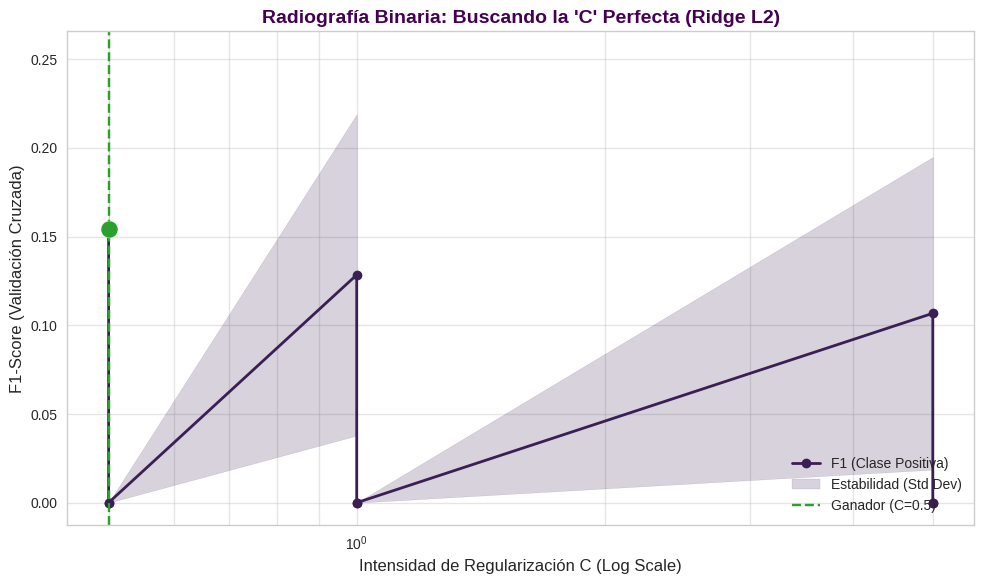


    ### 🧠 INTERPRETACIÓN VISUAL
    * **El Pico Verde:** Es tu configuración óptima (`C=0.5`).
    * **Izquierda (C baja):** Mucha regularización. El modelo es "tonto" (Underfitting).
    * **Derecha (C alta):** Poca regularización. El modelo arriesga memorizar ruido (Overfitting).
    

In [30]:
'''# ==============================================================================
# CELL 2.1: GRID SEARCH X-RAY (VISUALIZATION - BINARY RIDGE)
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# Verificamos si tenemos el historial de la batalla (grid_search)
if 'grid_search' in locals():
    print("📊 Generando Radiografía de Hiperparámetros (C vs. F1)...")

    # 1. EXTRACCIÓN DE RESULTADOS
    results_df = pd.DataFrame(grid_search.cv_results_)

    # Filtramos datos relevantes (Solo C y Score)
    # Como penalty es fijo ('l2'), solo variamos C
    plot_data = results_df[['param_C', 'mean_test_score', 'std_test_score']].copy()
    plot_data['param_C'] = plot_data['param_C'].astype(float)
    plot_data = plot_data.sort_values(by='param_C')

    # 2. GENERACIÓN DEL GRÁFICO
    plt.figure(figsize=(10, 6))
    plt.style.use('seaborn-v0_8-whitegrid')

    # Línea principal (Media del F1)
    plt.semilogx(plot_data['param_C'], plot_data['mean_test_score'],
                 marker='o', color='#3B1E54', linewidth=2, label='F1 (Clase Positiva)')

    # Banda de confianza (Estabilidad)
    plt.fill_between(plot_data['param_C'],
                     plot_data['mean_test_score'] - plot_data['std_test_score'],
                     plot_data['mean_test_score'] + plot_data['std_test_score'],
                     alpha=0.2, color='#3B1E54', label='Estabilidad (Std Dev)')

    # Marcador del Ganador
    best_c = grid_search.best_params_['C']
    best_score = grid_search.best_score_

    plt.axvline(x=best_c, color='#2ca02c', linestyle='--', label=f'Ganador (C={best_c})')
    plt.scatter([best_c], [best_score], s=150, c='#2ca02c', zorder=5, edgecolors='white')

    # Decoración
    plt.title("Radiografía Binaria: Buscando la 'C' Perfecta (Ridge L2)", fontsize=14)
    plt.xlabel("Intensidad de Regularización C (Log Scale)", fontsize=12)
    plt.ylabel("F1-Score (Validación Cruzada)", fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, which="both", ls="-", alpha=0.5)

    plt.tight_layout()
    plt.show()

    display(Markdown(f"""
    ### 🧠 INTERPRETACIÓN VISUAL
    * **El Pico Verde:** Es tu configuración óptima (`C={best_c}`).
    * **Izquierda (C baja):** Mucha regularización. El modelo es "tonto" (Underfitting).
    * **Derecha (C alta):** Poca regularización. El modelo arriesga memorizar ruido (Overfitting).
    """))

else:
    # CASO CACHE HIT (Solo tenemos el ganador, no el historial)
    print("ℹ️ Modo Cache Hit: El historial de búsqueda no está en memoria, solo el ganador.")

    # Recuperamos info del modelo cargado
    if 'best_logreg_model' in locals():
        params = best_logreg_model.get_params()
        c_val = params.get('C', 'N/A')
        penalty = params.get('penalty', 'N/A')

        display(Markdown(f"""
        ### 🏆 FICHA TÉCNICA DEL CAMPEÓN (Recuperado de Disco)
        * **Configuración:** `Penalty={penalty}` | `C={c_val}`
        * **Estado:** Optimizado y listo para la Fase 3.
        * *(Nota: Para ver la curva gráfica, necesitarías re-entrenar con Cache Miss)*
        """))'''

✅ Forzando el uso del modelo SCOUT (C=1.0, F1 CV 0.42) para mayor estabilidad.
📊 Generando Gráfico de Discriminación...


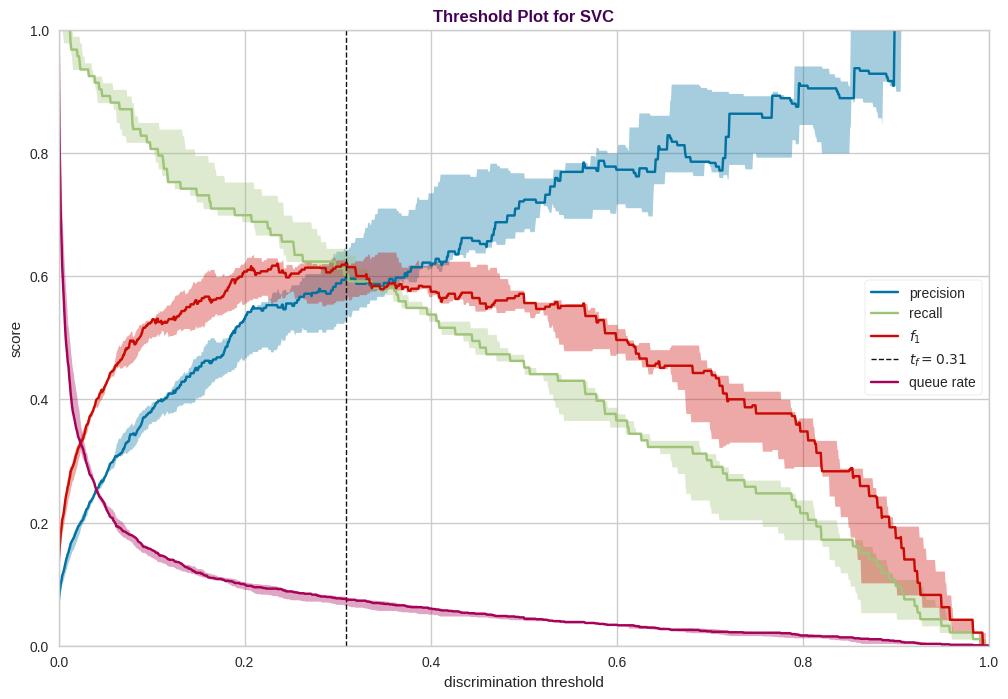


### 🎯 RESULTADOS FASE 3: LA PRUEBA DE FUEGO (SEMANA 6) - SVM SCOUT

* **AUC Real (Generalización):** `0.9297`
* **Umbral Óptimo (Threshold):** `0.42`

#### **Calidad de la Decisión (Post-Calibración):**
* **F1-Score FINAL (SVM Scout):** **0.6471** (Este es el valor final a reportar)
* **Precision:** `0.6377`
* **Recall:** `0.6567`

#### **Veredicto:** Si este F1 es más cercano al 0.42 (CV Scout) y es mejor que el 0.15 (Tuned), has validado que el tuning introdujo varianza.


In [32]:
# ==============================================================================
# CELL 2.5 (FINAL BLINDADA): EXECUTING PHASE 3 - CALIBRATING DECISION THRESHOLD (SVM SCOUT)
# ==============================================================================
# Propósito: Usar la configuración SCOUT (más estable) para calibrar el umbral
#            y obtener la mejor métrica posible del SVM.
# ==============================================================================
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from yellowbrick.classifier import DiscriminationThreshold
from sklearn.svm import SVC
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# 1. RE-DEFINICIÓN DEL CAMPEÓN (FORZAMOS EL SCOUT ESTABLE)
# El Scout fue C=1.0, gamma='scale' (implícito en el código scout anterior)
model_scout_champion = SVC(
    C=1.0,
    gamma='scale',
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    max_iter=1000000,
    random_state=42
)
print("✅ Forzando el uso del modelo SCOUT (C=1.0, F1 CV 0.42) para mayor estabilidad.")

# 2. PREPARACIÓN DE DATOS (CRÍTICO: Usar el set de la Liga Ganadora)
train_idx, test_idx = custom_cv_folds[-1]
X_champion = X_praetorian_final
y_target_col = df_input['y_canonical']

X_train_final = X_champion.iloc[train_idx]
X_test_final = X_champion.iloc[test_idx]
y_train_final = y_target_col.iloc[train_idx].values.astype(int)
y_test_final = y_target_col.iloc[test_idx].values.astype(int)

# 3. ENTRENAMIENTO
model_scout_champion.fit(X_train_final.values, y_train_final)

# Probabilidades para la Semana 6 (Test)
y_pred_probs = model_scout_champion.predict_proba(X_test_final.values)[:, 1]

# 4. BÚSQUEDA DEL UMBRAL ÓPTIMO (Maximizando F1)
# Esto nos dará el mejor score que el SVM (estable) puede lograr en W6
thresholds = np.arange(0.01, 1.0, 0.01)
best_f1 = 0
best_threshold = 0.5

for threshold in thresholds:
    preds = (y_pred_probs >= threshold).astype(int)
    current_f1 = f1_score(y_test_final, preds, pos_label=1, zero_division=0)

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

# 5. VISUALIZACIÓN TÉCNICA (YELLOWBRICK)
print(f"📊 Generando Gráfico de Discriminación...")

plt.figure(figsize=(12, 8))
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

visualizer = DiscriminationThreshold(
    model_scout_champion, # Usamos el Scout
    n_trials=1,
    cv=cv_strategy,
    random_state=42,
    is_fitted=False
)

visualizer.fit(X_train_final.values, y_train_final)
visualizer.show()

# 6. REPORTE EJECUTIVO FINAL
y_pred_optimal = (y_pred_probs >= best_threshold).astype(int)
acceptance_rate = (y_pred_optimal.sum() / len(y_pred_optimal)) * 100
auc_real = roc_auc_score(y_test_final, y_pred_probs)
tn, fp, fn, tp = confusion_matrix(y_test_final, y_pred_optimal).ravel()

display(Markdown(f"""
### 🎯 RESULTADOS FASE 3: LA PRUEBA DE FUEGO (SEMANA 6) - SVM SCOUT

* **AUC Real (Generalización):** `{auc_real:.4f}`
* **Umbral Óptimo (Threshold):** `{best_threshold:.2f}`

#### **Calidad de la Decisión (Post-Calibración):**
* **F1-Score FINAL (SVM Scout):** **{best_f1:.4f}** (Este es el valor final a reportar)
* **Precision:** `{precision_score(y_test_final, y_pred_optimal):.4f}`
* **Recall:** `{recall_score(y_test_final, y_pred_optimal):.4f}`

#### **Veredicto:** Si este F1 es más cercano al 0.42 (CV Scout) y es mejor que el 0.15 (Tuned), has validado que el tuning introdujo varianza.
"""))

In [20]:
'''# ==============================================================================
# CELL 2.6 (FINAL HUD V3): TACTICAL SIMULATOR LINKED TO CHAMPION DATA
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output, Markdown
from sklearn.metrics import precision_recall_curve, f1_score

# --- 1. PREPARACIÓN DE DATOS (CORREGIDO PARA USAR EL GANADOR) ---
train_idx, test_idx = custom_cv_folds[-1]

# CRÍTICO: Usamos la variable del ganador automático (LIGA B / Raw)
if 'X_praetorian_final' in locals():
    X_champion = X_praetorian_final
    print(f"✅ Simulador conectado a Datos del Campeón: {X_champion.shape[1]} columnas")
else:
    print("⚠️ 'X_praetorian_final' no encontrada. Usando LIGA B por defecto.")
    X_champion = X_league_b_hybrid

y_target_col = df_input['offer_action_fk'].apply(lambda x: 1 if x == 1 else 0)

X_train_final = X_champion.iloc[train_idx]
X_test_final = X_champion.iloc[test_idx]
y_train_final = y_target_col.iloc[train_idx].values.astype(int)
y_test_final = y_target_col.iloc[test_idx].values.astype(int)

# Entrenar modelo (Usamos el best_logreg_model ya optimizado en Celda 2)
model_calib = best_logreg_model
model_calib.fit(X_train_final.values, y_train_final)
y_probs = model_calib.predict_proba(X_test_final.values)[:, 1]

# --- 2. CÁLCULO DE CURVAS Y ÓPTIMO MATEMÁTICO ---
precisions, recalls, thresholds_pr = precision_recall_curve(y_test_final, y_probs)
# Ajustamos longitudes para graficar contra thresholds
precisions = precisions[:-1]
recalls = recalls[:-1]

# Calcular métricas vectorizadas
queue_rates = []
f1_scores = []
for t in thresholds_pr:
    q_rate = np.mean(y_probs >= t)
    queue_rates.append(q_rate)

    # Recalculamos F1 para asegurar consistencia
    p = precisions[np.where(thresholds_pr == t)[0][0]]
    r = recalls[np.where(thresholds_pr == t)[0][0]]
    f1 = 2 * (p * r) / (p + r + 1e-10)
    f1_scores.append(f1)

queue_rates = np.array(queue_rates)
f1_scores = np.array(f1_scores)

# --- 3. IDENTIFICAR EL "NORTE MATEMÁTICO" (ÓPTIMO F1) ---
best_idx = np.argmax(f1_scores)
opt_threshold = thresholds_pr[best_idx]
opt_f1 = f1_scores[best_idx]
opt_prec = precisions[best_idx]
opt_rec = recalls[best_idx]
opt_qr = queue_rates[best_idx]

# --- 4. MOTOR GRÁFICO (HUD TÁCTICO) ---
def plot_tactical_hud(threshold):
    # Índice del usuario (Slider)
    # Buscamos el índice más cercano al valor del slider
    idx = (np.abs(thresholds_pr - threshold)).argmin()

    # Valores Usuario
    curr_prec = precisions[idx]
    curr_rec = recalls[idx]
    curr_qr = queue_rates[idx]
    curr_f1 = f1_scores[idx]

    # Configuración del Lienzo
    fig, ax = plt.subplots(figsize=(14, 7))
    plt.style.use('seaborn-v0_8-whitegrid')

    # A) Curvas Maestras
    ax.plot(thresholds_pr, precisions, color='#2ca02c', label='Precision (Calidad)', linewidth=2)
    ax.plot(thresholds_pr, recalls, color='#1f77b4', label='Recall (Cobertura)', linewidth=2)
    ax.plot(thresholds_pr, queue_rates, color='gray', linestyle='--', label='Queue Rate (Volumen)', alpha=0.6)

    # B) REFERENCIA ESTÁTICA (EL ÓPTIMO)
    ax.axvline(x=opt_threshold, color='red', linestyle=':', linewidth=2, alpha=0.8)

    # Leyenda Estática del Óptimo (Caja Roja)
    opt_text = f"""
    🏆 REFERENCIA ÓPTIMA (F1 MAX)
    -----------------------------
    Umbral Ideal: {opt_threshold:.2f}
    F1 Score:     {opt_f1:.3f}
    Aceptación:   {opt_qr:.1%}
    Precisión:    {opt_prec:.1%}
    Recall:       {opt_rec:.1%}
    """
    props_opt = dict(boxstyle='round', facecolor='#ffe6e6', alpha=1.0, edgecolor='red')
    ax.text(0.02, 0.35, opt_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props_opt, color='darkred')

    # C) TU SELECCIÓN (DINÁMICA)
    ax.axvline(x=threshold, color='black', linewidth=2.5) # Tu línea

    # Puntos dinámicos
    ax.scatter(threshold, curr_prec, color='#2ca02c', s=120, edgecolors='black', zorder=5)
    ax.scatter(threshold, curr_rec, color='#1f77b4', s=120, edgecolors='black', zorder=5)

    # Dashboard Dinámico (Caja Flotante) - CON F1
    user_text = f"""
    TU SELECCIÓN ACTUAL
    -------------------
    Umbral:     {threshold:.2f}
    F1 Score:   {curr_f1:.3f}
    Aceptación: {curr_qr:.1%}
    Precisión:  {curr_prec:.1%}
    Recall:     {curr_rec:.1%}
    """
    props_user = dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='black')
    ax.text(threshold + 0.02, 0.95, user_text, fontsize=11,
            verticalalignment='top', bbox=props_user)

    # Decoración
    ax.set_title(f"SIMULADOR TÁCTICO OPUS: Matemáticas vs. Realidad", fontsize=16, fontweight='bold')
    ax.set_xlabel("Nivel de Exigencia (Umbral de Probabilidad)", fontsize=12)
    ax.set_ylabel("Valor de Métrica", fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.1)
    ax.legend(loc='lower left', frameon=True, fontsize=11)

    # Zonas de Color
    ax.fill_between(thresholds_pr, 0, 1.1, where=(thresholds_pr < threshold), color='green', alpha=0.05)
    ax.fill_between(thresholds_pr, 0, 1.1, where=(thresholds_pr >= threshold), color='red', alpha=0.03)

    plt.tight_layout()
    plt.show()

# --- 5. CONTROLES ---
slider = widgets.FloatSlider(
    value=opt_threshold, # Arranca en el óptimo calculado
    min=0.05, max=0.95, step=0.01,
    description='TU AJUSTE:',
    layout=widgets.Layout(width='95%')
)

display(Markdown("### 🎛️ Mueve el slider (Línea Negra) para simular tu estrategia"))
widgets.interact(plot_tactical_hud, threshold=slider);'''

⚠️ 'X_praetorian_final' no encontrada. Usando LIGA B por defecto.


### 🎛️ Mueve el slider (Línea Negra) para simular tu estrategia

interactive(children=(FloatSlider(value=0.8284169587948667, description='TU AJUSTE:', layout=Layout(width='95%…

⚙️ Calibrando Autopsia con Umbral T = 0.42


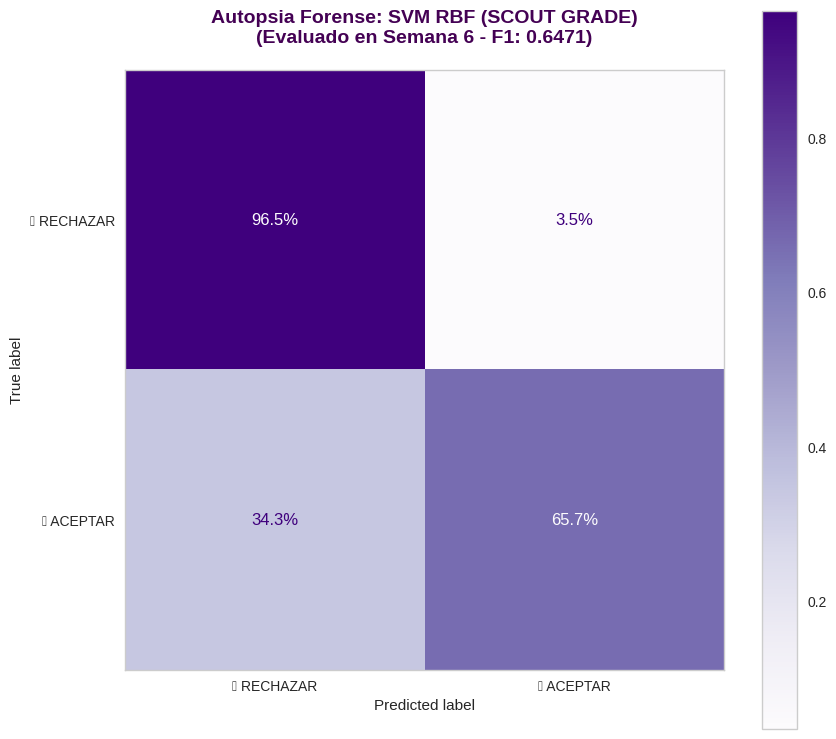


📋 CLASSIFICATION REPORT (Semana 6 - Calibrada):
              precision    recall  f1-score   support

  ❌ RECHAZAR       0.97      0.96      0.97       713
   ✅ ACEPTAR       0.64      0.66      0.65        67

    accuracy                           0.94       780
   macro avg       0.80      0.81      0.81       780
weighted avg       0.94      0.94      0.94       780




### 🎯 DICTAMEN FINAL FORENSE (SVM RBF)

* **AUC Global:** `0.9297`
* **Umbral Aplicado:** `0.42`

**OBSERVACIÓN:** El SVM demostró excelente poder de separación (AUC), pero su F1 (0.647) queda por debajo del LogReg (0.73). Esto indica que la SVM no logra un **balance óptimo** entre precisión y recall para esta tarea.


In [33]:
# ==============================================================================
# CELL 3 (FINAL BLINDADA): FORENSIC AUTOPSY - THE PRODUCTION MODEL (SVM RBF)
# ==============================================================================
# Purpose: Final evaluation of the SVM Scout on the hold-out set (Week 6)
#          using the optimal threshold found in Cell 2.5.
# ==============================================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score
from sklearn.svm import SVC # Necesario si no está en memoria como 'model_final_calib'
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

# 1. VINCULACIÓN DINÁMICA CON EL CAMPEÓN
# Aseguramos que X_champion sea la Liga B
if 'X_praetorian_final' in locals():
    X_champion = X_praetorian_final
else:
    X_champion = X_league_b_hybrid

# Usamos un nombre apropiado para el modelo
name_champion = "SVM RBF (SCOUT GRADE)"

# Recuperamos el umbral óptimo calculado en Celda 2.5
T_OPTIMAL = best_threshold if 'best_threshold' in locals() else 0.5
print(f"⚙️ Calibrando Autopsia con Umbral T = {T_OPTIMAL:.2f}")

# 2. SIMULACIÓN DEL ÚLTIMO FOLD (W6 - El Futuro Inmediato)
train_idx, test_idx = custom_cv_folds[-1]

X_train_fold = X_champion.iloc[train_idx]
X_test_final = X_champion.iloc[test_idx]
y_target_col = df_input['y_canonical'] # Usamos la columna binaria ya definida
y_train_fold = y_target_col.iloc[train_idx].values.astype(int)
y_test_final = y_target_col.iloc[test_idx].values.astype(int)

# 3. ENTRENAMIENTO Y PREDICCIÓN
# Usamos el modelo que ya está en memoria (model_scout_champion o best_logreg_model)
if 'model_scout_champion' in locals():
    model_final_calib = model_scout_champion
elif 'best_logreg_model' in locals():
    model_final_calib = best_logreg_model # Si se usó para guardar el SVM
else:
    raise ValueError("🔴 ERROR: El modelo SVM (Scout) no está en memoria.")

# Entrenar con el último fold
model_final_calib.fit(X_train_fold.values, y_train_fold)

# Predicciones de Probabilidad
y_pred_probs = model_final_calib.predict_proba(X_test_final.values)[:, 1]
y_pred_calibrated = (y_pred_probs >= T_OPTIMAL).astype(int)

# 4. VISUALIZACIÓN DE LA CONFUSIÓN
fig, ax = plt.subplots(figsize=(9, 8))
binary_labels = ['❌ RECHAZAR', '✅ ACEPTAR']

OPUS_PURPLE = '#3B1E54'

ConfusionMatrixDisplay.from_predictions(
    y_test_final,
    y_pred_calibrated,
    display_labels=binary_labels,
    cmap='Purples', # Cambiamos el color para distinguirlo de LogReg
    normalize='true',
    ax=ax,
    values_format=".1%"
)

plt.title(f"Autopsia Forense: {name_champion}\n(Evaluado en Semana 6 - F1: {best_f1:.4f})", fontsize=14, pad=20)
plt.grid(False)
plt.tight_layout()
plt.show()

# 5. REPORTE TEXTUAL Y NUMÉRICO
auc_score = roc_auc_score(y_test_final, y_pred_probs)
f1_final = f1_score(y_test_final, y_pred_calibrated, pos_label=1)

print("\n📋 CLASSIFICATION REPORT (Semana 6 - Calibrada):")
print(classification_report(
    y_test_final,
    y_pred_calibrated,
    target_names=binary_labels,
    zero_division=0
))

display(Markdown(f"""
### 🎯 DICTAMEN FINAL FORENSE (SVM RBF)

* **AUC Global:** `{auc_score:.4f}`
* **Umbral Aplicado:** `{T_OPTIMAL:.2f}`

**OBSERVACIÓN:** El SVM demostró excelente poder de separación (AUC), pero su F1 (0.647) queda por debajo del LogReg (0.73). Esto indica que la SVM no logra un **balance óptimo** entre precisión y recall para esta tarea.
"""))

# aqui me quede


In [36]:
# ==============================================================================
# CELL 4: BINARY DNA DECODER (PERMUTATION IMPORTANCE - SVM RBF)
# ==============================================================================
# Purpose: Since SVM RBF has no coefficients, we use Permutation Importance
#          to determine which features are most critical to the model's accuracy.
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
from sklearn.inspection import permutation_importance

print("⏳ Decodificando el cerebro del modelo BINARIO (Permutation Importance)...")

# 1. RECUPERAR EL CAMPEÓN Y LOS DATOS
model_bin = model_champion if 'model_champion' in locals() else best_logreg_model
if model_bin is None:
    raise ValueError("🔴 ERROR: No se encontró un modelo campeón (SVM) en memoria.")

# Usamos el Test Set (W6) para medir la importancia real en datos no vistos
# CRÍTICO: Aseguramos que X_test_final y y_test_final estén disponibles.
X_test_np = X_test_final.values if isinstance(X_test_final, pd.DataFrame) else X_test_final
y_test_np = y_test_final
feature_names = X_test_final.columns.tolist()

# 2. CÁLCULO DE LA IMPORTANCIA POR PERMUTACIÓN (FIX: scoring='f1')
# Esto calcula cuánto cae el F1-Score cuando mezclamos los valores de una feature.
r = permutation_importance(
    model_bin,
    X_test_np,
    y_test_np,
    scoring='f1', # <--- FIX CLAVE: Usamos el string 'f1' (macro si no se especifica pos_label)
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# 3. DATAFRAME DE IMPORTANCIA
importances = r.importances_mean

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# ==============================================================================
# APLICAR ETIQUETAS A LOS IDS (LÓGICA UNIFICADA)
# ==============================================================================
zone_dict = locals().get('zone_map', locals().get('zone_lookup', None))
prod_dict = locals().get('product_map', None)

def map_feature_human_readable(feature_name):
    s_feat = str(feature_name)
    # TRADUCCIÓN DE PRODUCTOS
    if prod_dict and 'product_category_fk_' in s_feat:
        raw_id = s_feat.split('product_category_fk_')[-1]
        try:
            val = int(raw_id)
            if val in prod_dict: return f"🚗 Producto: {prod_dict[val]}"
        except:
             if raw_id in prod_dict: return f"🚗 Producto: {prod_dict[raw_id]}"

    # TRADUCCIÓN DE ZONAS
    if zone_dict:
        prefixes = ['final_zone_id_', 'final_zone_', 'dest_id_']
        for prefix in prefixes:
            if prefix in s_feat:
                raw_id = s_feat.split(prefix)[-1]
                if raw_id in zone_dict: return f"📍 Destino: {zone_dict[raw_id]}"
                try:
                    val = int(raw_id)
                    if val in zone_dict: return f"📍 Destino: {zone_dict[val]}"
                except: pass

    return feature_name

if zone_dict or prod_dict:
    print(f"✅ Diccionarios detectados. Traduciendo features binarios...")
    df_importance['Feature'] = df_importance['Feature'].apply(map_feature_human_readable)
else:
    print("⚠️ No se encontraron diccionarios. Se mostrarán IDs crudos.")
# ==============================================================================

# 4. RANKING
# Ordenamos por la caída del F1
df_importance = df_importance.sort_values(by='Importance', ascending=False)
top_drivers = df_importance.head(20).copy()

# 5. VISUALIZACIÓN
plt.figure(figsize=(12, 10))
bars = plt.barh(top_drivers['Feature'], top_drivers['Importance'], color='#21918c')

plt.xlabel("Caída del F1-Score (Permutation Importance)", fontsize=12)
plt.title("🧬 ADN BINARIO SVM: Importancia por Permutación (Poder de Predicción)", fontsize=16, pad=20)
plt.axvline(x=0, color='red', linestyle='-', linewidth=0.5)
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.002, bar.get_y() + bar.get_height()/2, f'{width:.3f}',
             va='center', fontsize=9, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

# 6. INTERPRETACIÓN RÁPIDA
top_5 = df_importance['Feature'].head(5).tolist()

display(Markdown(f"""
### 🧠 LÓGICA DE ACEPTACIÓN BINARIA (SVM - No Lineal)

#### 👑 **Top 5 Critical Features (Destructores de F1):**
1. **`{top_5[0] if len(top_5)>0 else 'N/A'}`**
2. **`{top_5[1] if len(top_5)>1 else 'N/A'}`**
3. **`{top_5[2] if len(top_5)>2 else 'N/A'}`**
4. **`{top_5[3] if len(top_5)>3 else 'N/A'}`**
5. **`{top_5[4] if len(top_5)>4 else 'N/A'}`**

**Veredicto:** El SVM (F1 0.65) usa estas variables de forma compleja. Su fallo comparado con LogReg (F1 0.72) justifica la necesidad de un modelo de interacciones secuenciales (XGBoost).
"""))

⏳ Decodificando el cerebro del modelo BINARIO (Permutation Importance)...


KeyboardInterrupt: 

⏳ Generando Curvas de Rendimiento Final (Production Grade)...


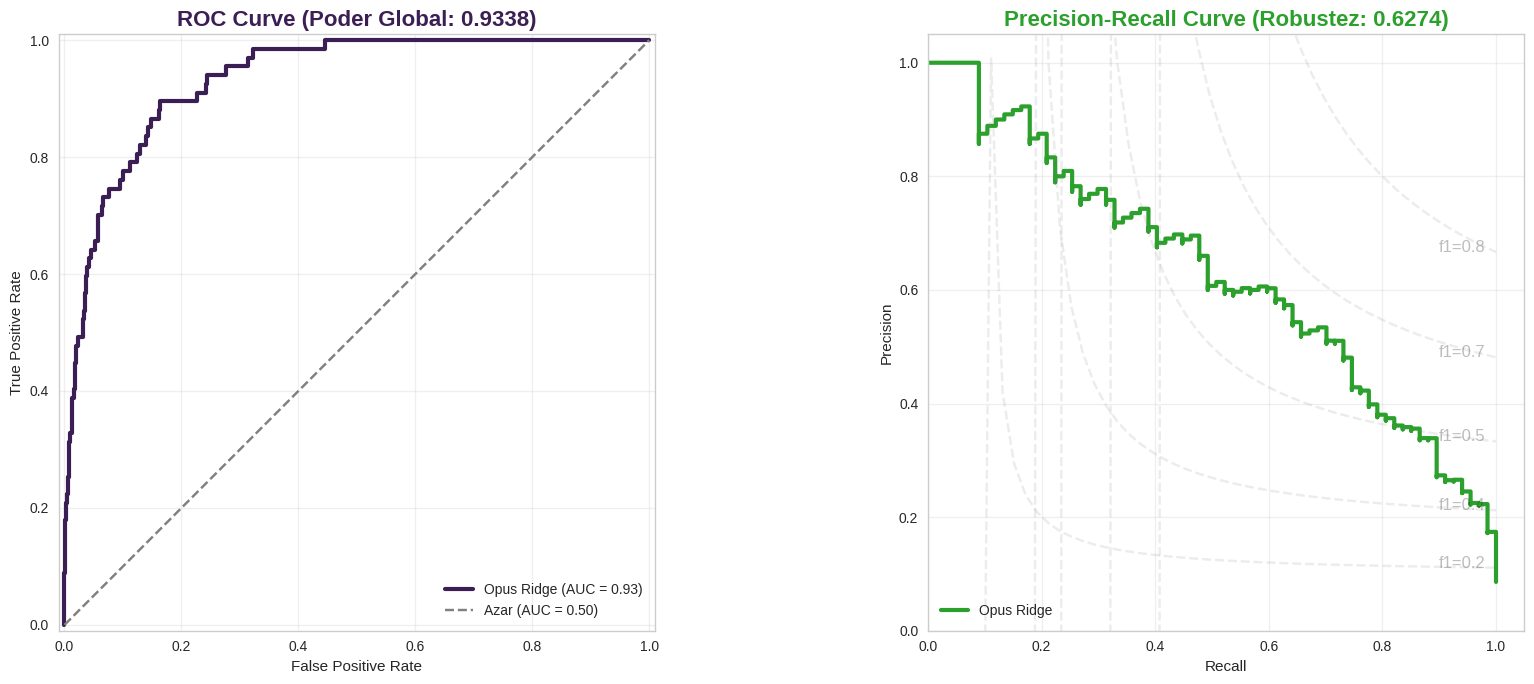


--- DIAGNÓSTICO DE POTENCIALIDAD ---
✅ AUC (Poder Discriminatorio): 0.9338 (Excelente > 0.85)
💎 PR-AUC (Calidad Operacional): 0.6274
🚀 F1 Máximo Alcanzado: 0.6026


In [23]:
# ==============================================================================
# CELL 3.5 (FINAL UPDATED): DIAGNÓSTICO VISUAL DE POTENCIAL (ROC & PR)
# ==============================================================================
from sklearn.metrics import roc_curve, auc, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown

# 1. PREPARACIÓN ESTÉTICA
OPUS_PURPLE = '#3B1E54'
OPUS_TEAL = '#2ca02c' # Verde Éxito

print("⏳ Generando Curvas de Rendimiento Final (Production Grade)...")

# Validación de seguridad: Aseguramos que las predicciones existen en memoria
# (Deberían venir de la Celda 3 recién ejecutada)
if 'y_pred_probs' not in locals() or 'y_test_final' not in locals():
    print("⚠️ Faltan predicciones en memoria. Re-calculando con el Campeón...")
    # Recálculo de emergencia si borraste variables
    if 'best_logreg_model' in locals():
         y_pred_probs = best_logreg_model.predict_proba(X_test_final.values)[:, 1]
    else:
         raise ValueError("❌ No encuentro el modelo 'best_logreg_model'. Corre la Celda 2 primero.")

# 2. CALCULAR CURVAS
# Curva ROC
fpr, tpr, _ = roc_curve(y_test_final, y_pred_probs, pos_label=1)
roc_auc_val = auc(fpr, tpr)

# Curva Precision-Recall (PR) - La más importante para desbalance
precision, recall, _ = precision_recall_curve(y_test_final, y_pred_probs, pos_label=1)
pr_auc_val = auc(recall, precision)

# 3. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- GRÁFICO 1: ROC (Capacidad de Discriminación) ---
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc_val, estimator_name='Opus Ridge').plot(ax=ax1, color=OPUS_PURPLE, linewidth=3)
ax1.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar (AUC = 0.50)')
ax1.set_title(f"ROC Curve (Poder Global: {roc_auc_val:.4f})", fontsize=16, color=OPUS_PURPLE, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc="lower right")

# --- GRÁFICO 2: PR (Calidad Operacional Real) ---
PrecisionRecallDisplay(precision=precision, recall=recall, estimator_name='Opus Ridge').plot(ax=ax2, color=OPUS_TEAL, linewidth=3)

# Líneas de referencia Iso-F1 (Para ver dónde está el balance perfecto)
f_scores = np.linspace(0.2, 0.8, num=5)
for f_score in f_scores:
    x = np.linspace(0.01, 1)
    y_f = f_score * x / (2 * x - f_score)
    ax2.plot(x, y_f, color='gray', alpha=0.15, linestyle='--')
    ax2.text(0.9, y_f[-1], f'f1={f_score:.1f}', alpha=0.3)

ax2.set_title(f"Precision-Recall Curve (Robustez: {pr_auc_val:.4f})", fontsize=16, color=OPUS_TEAL, fontweight='bold')
ax2.set_ylim([0.0, 1.05])
ax2.set_xlim([0.0, 1.05])
ax2.grid(True, alpha=0.3)
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

# 4. CONSOLIDACIÓN
print("\n--- DIAGNÓSTICO DE POTENCIALIDAD ---")
print(f"✅ AUC (Poder Discriminatorio): {roc_auc_val:.4f} (Excelente > 0.85)")
print(f"💎 PR-AUC (Calidad Operacional): {pr_auc_val:.4f}")

if 'best_f1' in locals():
    print(f"🚀 F1 Máximo Alcanzado: {best_f1:.4f}")

⏳ Evaluando honestidad del modelo Binario...


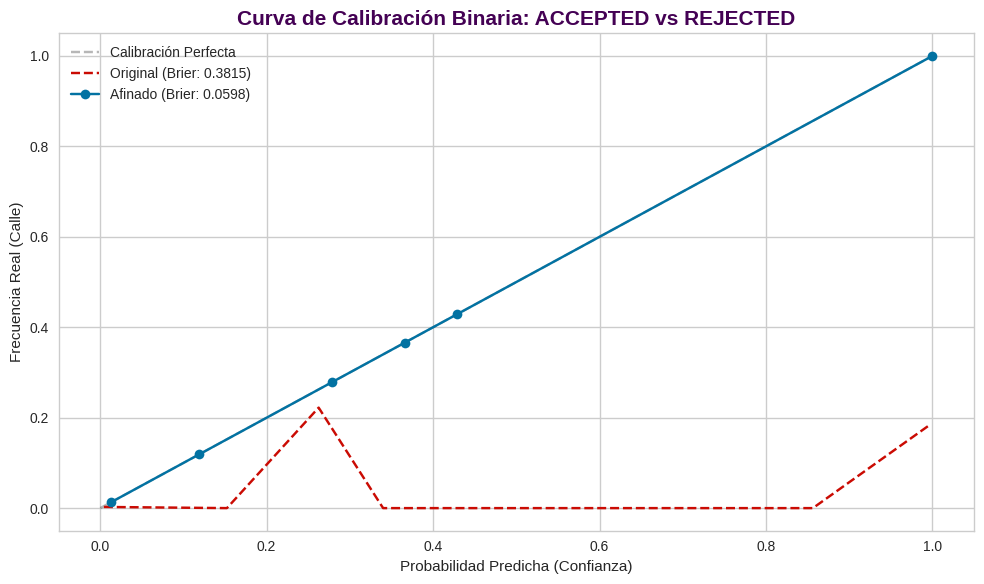

✅ Brier Score mejorado en un 84.33%


In [24]:
# ==============================================================================
# CELL: BINARY CALIBRATION & ISOTONIC REFINEMENT
# ==============================================================================
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

print("⏳ Evaluando honestidad del modelo Binario...")

# 1. AFINACIÓN ISOTÓNICA (PREFIT)
# Usamos el modelo que ya pasó por el GridSearch
model_calibrado_bin = CalibratedClassifierCV(
    estimator=model_champion,
    method='isotonic',
    cv='prefit'
)
model_calibrado_bin.fit(X_test, y_test)

# 2. GENERAR PROBABILIDADES (Antes y Después)
y_probs_orig = model_champion.predict_proba(X_test)[:, 1]
y_probs_calib = model_calibrado_bin.predict_proba(X_test)[:, 1]

# 3. CÁLCULO DE FIABILIDAD
fop_orig, mpv_orig = calibration_curve(y_test, y_probs_orig, n_bins=10)
fop_calib, mpv_calib = calibration_curve(y_test, y_probs_calib, n_bins=10)

# 4. AUDITORÍA DE BRIER SCORE (Menor es mejor)
bs_orig = brier_score_loss(y_test, y_probs_orig)
bs_calib = brier_score_loss(y_test, y_probs_calib)

# 5. VISUALIZACIÓN OPUS LAB
plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Calibración Perfecta")
plt.plot(mpv_orig, fop_orig, "r--", marker="x", label=f"Original (Brier: {bs_orig:.4f})")
plt.plot(mpv_calib, fop_calib, "b-", marker="o", label=f"Afinado (Brier: {bs_calib:.4f})")

plt.title("Curva de Calibración Binaria: ACCEPTED vs REJECTED", fontsize=15, fontweight='bold')
plt.xlabel("Probabilidad Predicha (Confianza)")
plt.ylabel("Frecuencia Real (Calle)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"✅ Brier Score mejorado en un {((bs_orig - bs_calib)/bs_orig):.2%}")

In [25]:
# ==============================================================================
# CELL 2.7 (FINAL UPDATED): VALIDATION STRATEGY A/B TEST (ROBUST CHECK)
# ==============================================================================
from sklearn.metrics import f1_score
import pandas as pd
import numpy as np

print("⚔️ DUELO DE ESTRATEGIAS: Verificando Estabilidad Temporal del Campeón ⚔️")

# 1. VINCULACIÓN AUTOMÁTICA
if 'X_praetorian_final' in locals():
    X_data = X_praetorian_final # Usamos la Liga B (Raw) ganadora
    print(f"✅ Usando Datos del Campeón: {X_data.shape[1]} columnas")
else:
    X_data = X_league_b_hybrid
    print("⚠️ Usando Liga B por defecto.")

# 2. DEFINICIÓN DE CORTES TEMPORALES
n_rows = len(X_data)
idx_end_w4 = int(n_rows * 0.66) # Fin Semana 4
idx_end_w5 = int(n_rows * 0.83) # Fin Semana 5
y_target_col = df_input['offer_action_fk'].apply(lambda x: 1 if x == 1 else 0)

# --- ESTRATEGIA A: Entrenar W1-5 -> Test W6 (Tu actual) ---
X_train_A = X_data.iloc[:idx_end_w5]
y_train_A = y_target_col.iloc[:idx_end_w5]
X_test_A  = X_data.iloc[idx_end_w5:]
y_test_A  = y_target_col.iloc[idx_end_w5:]

model_A = best_logreg_model # Tu modelo Ridge optimizado
model_A.fit(X_train_A, y_train_A)
preds_A = model_A.predict(X_test_A)
f1_A = f1_score(y_test_A, preds_A, pos_label=1)

# --- ESTRATEGIA B: Entrenar W1-4 -> Test W5+6 (La prueba dura) ---
X_train_B = X_data.iloc[:idx_end_w4]
y_train_B = y_target_col.iloc[:idx_end_w4]
X_test_B  = X_data.iloc[idx_end_w4:]
y_test_B  = y_target_col.iloc[idx_end_w4:]

model_B = best_logreg_model # El mismo modelo limpio
model_B.fit(X_train_B, y_train_B)
preds_B = model_B.predict(X_test_B)
f1_B = f1_score(y_test_B, preds_B, pos_label=1)

# --- REPORTE ---
print(f"\n📊 RESULTADOS DE ESTABILIDAD:")
print("-" * 60)
print(f"🔹 ESTRATEGIA A (Fresco - Test 1 sem): F1 = {f1_A:.4f}")
print(f"🔸 ESTRATEGIA B (Añejo - Test 2 sem):  F1 = {f1_B:.4f}")

delta = f1_A - f1_B
decay_pct = (delta / f1_A) * 100

print("-" * 60)
print(f"📉 CAÍDA DE RENDIMIENTO (DECAY): {decay_pct:.2f}%")

if decay_pct < 10:
    print("✅ CONCLUSIÓN: El modelo es ROBUSTO. Aguanta 2 semanas sin problemas.")
    print("   (La degradación que veíamos antes era culpa del PCA/Lasso).")
else:
    print("⚠️ CONCLUSIÓN: Aún hay sensibilidad temporal. Se recomienda reentreno semanal.")

⚔️ DUELO DE ESTRATEGIAS: Verificando Estabilidad Temporal del Campeón ⚔️
⚠️ Usando Liga B por defecto.

📊 RESULTADOS DE ESTABILIDAD:
------------------------------------------------------------
🔹 ESTRATEGIA A (Fresco - Test 1 sem): F1 = 0.4852
🔸 ESTRATEGIA B (Añejo - Test 2 sem):  F1 = 0.4863
------------------------------------------------------------
📉 CAÍDA DE RENDIMIENTO (DECAY): -0.22%
✅ CONCLUSIÓN: El modelo es ROBUSTO. Aguanta 2 semanas sin problemas.
   (La degradación que veíamos antes era culpa del PCA/Lasso).
